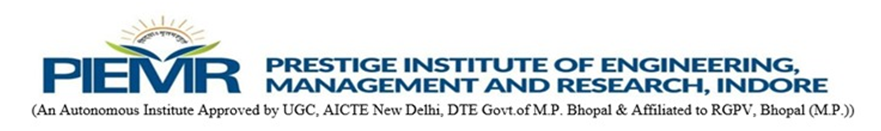

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

<h2 align="left">Experiment 9</h2>

<h2 align="left">DBSCAN Clustering using Moons Dataset</h2>

<h2 align="left">Objective</h2>

To implement the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) clustering algorithm using the synthetic Moons Dataset and identify clusters and noise points.



What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together closely packed data points and marks isolated points as noise (outliers).

Unlike K-Means:

DBSCAN does not require the number of clusters beforehand
Can detect arbitrary shaped clusters
Handles noise and outliers effectively

Key Concepts in DBSCAN

| Concept       | Meaning                                      |
| ------------- | -------------------------------------------- |
| Core Point    | Point having sufficient neighboring points   |
| Border Point  | Near a core point but with fewer neighbors   |
| Noise Point   | Isolated point                               |
| Epsilon (eps) | Neighborhood radius                          |
| min_samples   | Minimum points required to form dense region |




Python Libraries Used

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons

from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score



STEP 1: Generate Moons Dataset

In [3]:
X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)



Explanation


| Parameter       | Meaning               |
| --------------- | --------------------- |
| n_samples=500   | Total data points     |
| noise=0.08      | Adds randomness/noise |
| random_state=42 | Reproducible results  |




STEP 2: Visualize Original Dataset

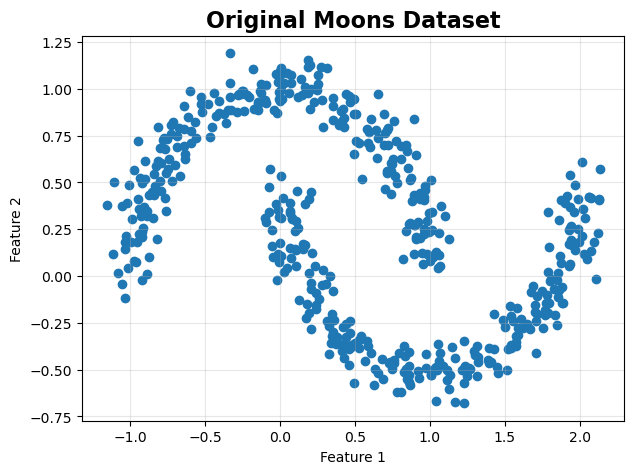

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.title(
    "Original Moons Dataset",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(alpha=0.3)

plt.show()



Explanation

The moons dataset contains:


two non-linear moon-shaped clusters
overlapping/noisy points


This dataset is ideal for DBSCAN because:


K-Means struggles with non-linear shapes

DBSCAN handles arbitrary shapes effectively

STEP 3: Apply DBSCAN Algorithm

In [5]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

clusters = dbscan.fit_predict(X)



Parameter Explanation

| Parameter     | Meaning                    |
| ------------- | -------------------------- |
| eps=0.2       | Neighborhood radius        |
| min_samples=5 | Minimum neighboring points |





STEP 4: Check Cluster Labels

In [6]:
print("Cluster Labels:\n")

print(np.unique(clusters))



Cluster Labels:

[0 1]


Explanation


| Label | Meaning      |
| ----- | ------------ |
| 0     | Cluster 1    |
| 1     | Cluster 2    |
| -1    | Noise points |


STEP 5: Visualize DBSCAN Clusters

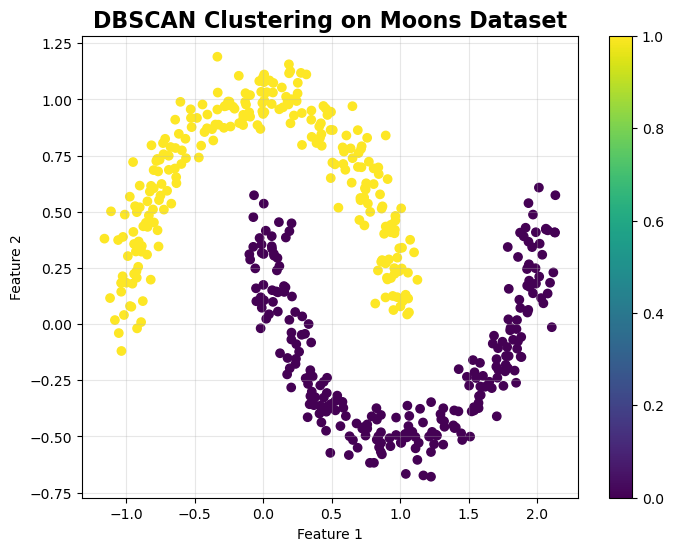

In [7]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title(
    "DBSCAN Clustering on Moons Dataset",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(alpha=0.3)

plt.colorbar(scatter)

plt.show()




Explanation

The graph shows:

different cluster colors

separated moon structures

noise/outlier points

STEP 6: Highlight Noise Points

DBSCAN labels noise as:
-1

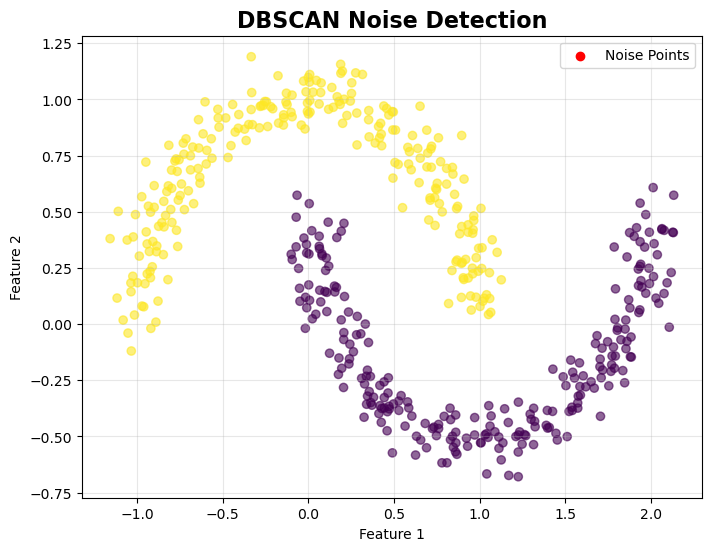

In [9]:
noise_points = X[clusters == -1]

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap='viridis',
    alpha=0.6
)

plt.scatter(
    noise_points[:,0],
    noise_points[:,1],
    color='red',
    label='Noise Points'
)

plt.title(
    "DBSCAN Noise Detection",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.grid(alpha=0.3)

plt.show()




STEP 7: Number of Clusters

In [10]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of Clusters:", n_clusters)



Number of Clusters: 2


STEP 8: Number of Noise Points

In [11]:
noise_count = list(clusters).count(-1)

print("Number of Noise Points:", noise_count)



Number of Noise Points: 0


STEP 9: Silhouette Score

Silhouette Score measures clustering quality.

In [12]:
score = silhouette_score(X, clusters)

print("Silhouette Score:", score)



Silhouette Score: 0.33057612844631057


Explanation

| Score Value | Interpretation       |
| ----------- | -------------------- |
| Near +1     | Good clustering      |
| Near 0      | Overlapping clusters |
| Near -1     | Poor clustering      |



STEP 10: Compare Original vs Clustered Data

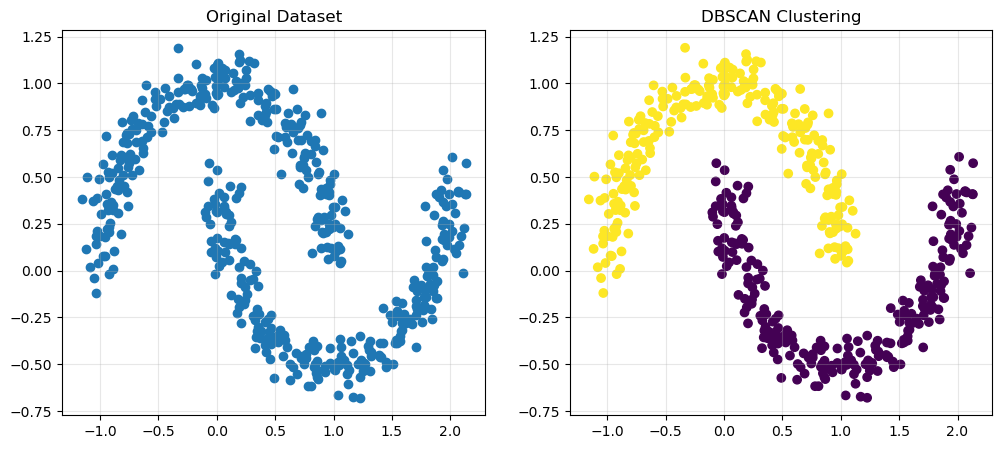

In [13]:
plt.figure(figsize=(12,5))

# Original Data
plt.subplot(1,2,1)

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.title("Original Dataset")

plt.grid(alpha=0.3)

# DBSCAN Result
plt.subplot(1,2,2)

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("DBSCAN Clustering")

plt.grid(alpha=0.3)

plt.show()

Final Result


The DBSCAN algorithm successfully identified moon-shaped clusters and detected noise points from the synthetic moons dataset.

Advantages of DBSCAN

Detects arbitrary shaped clusters

No need to specify cluster count

Handles noise and outliers

Works well for non-linear data

Limitations

Sensitive to eps value

Difficult for varying density datasets

Performance decreases in high dimensions

Viva Questions

Q1. What is DBSCAN?


DBSCAN is a density-based clustering algorithm.


Q2. What is the role of eps?


It defines neighborhood radius.

Q3. What are noise points?


Points not belonging to any cluster.

Q4. Why DBSCAN is better than K-Means for moons dataset?


Because DBSCAN handles non-linear cluster shapes.


Q5. What does label -1 represent?

Noise or outlier points.




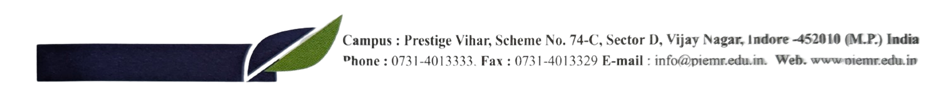